# Phase 1 — Step 2: Exploratory Data Analysis

**Goal:** Use DuckDB SQL to aggregate and Polars to shape the data, then produce 4 diagnostic charts.

**Stack:** DuckDB · Polars · Matplotlib · Seaborn

In [1]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

FIGURES = "../data/figures"
DB_PATH = "../data/apex.duckdb"
os.makedirs(FIGURES, exist_ok=True)
sns.set_theme(style="darkgrid")
print("Setup complete.")


Setup complete.


In [2]:
conn = duckdb.connect(DB_PATH, read_only=True)   # read-only — never locks the file

# Safety check
tables = [t[0] for t in conn.execute("SHOW TABLES").fetchall()]
if "raw_logs" not in tables:
    conn.close()
    raise RuntimeError("raw_logs table missing. Run 1_generate_server_logs.ipynb first.")

# Load into Polars and add hour column
df = (conn.execute("SELECT * FROM raw_logs").pl()
          .with_columns(
              pl.col("timestamp").str.to_datetime("%Y-%m-%d %H:%M:%S"),
              pl.col("execution_time_ms").cast(pl.Float64),
              pl.col("server_cpu_load").cast(pl.Float64),
          )
          .with_columns(pl.col("timestamp").dt.hour().alias("hour_of_day"))
     )

print(f"Loaded  {len(df):,} rows from DuckDB  →  raw_logs")
print(df.dtypes)

Loaded  15,000 rows from DuckDB  →  raw_logs
[Datetime(time_unit='us', time_zone=None), String, String, Float64, Float64, String, Int8]


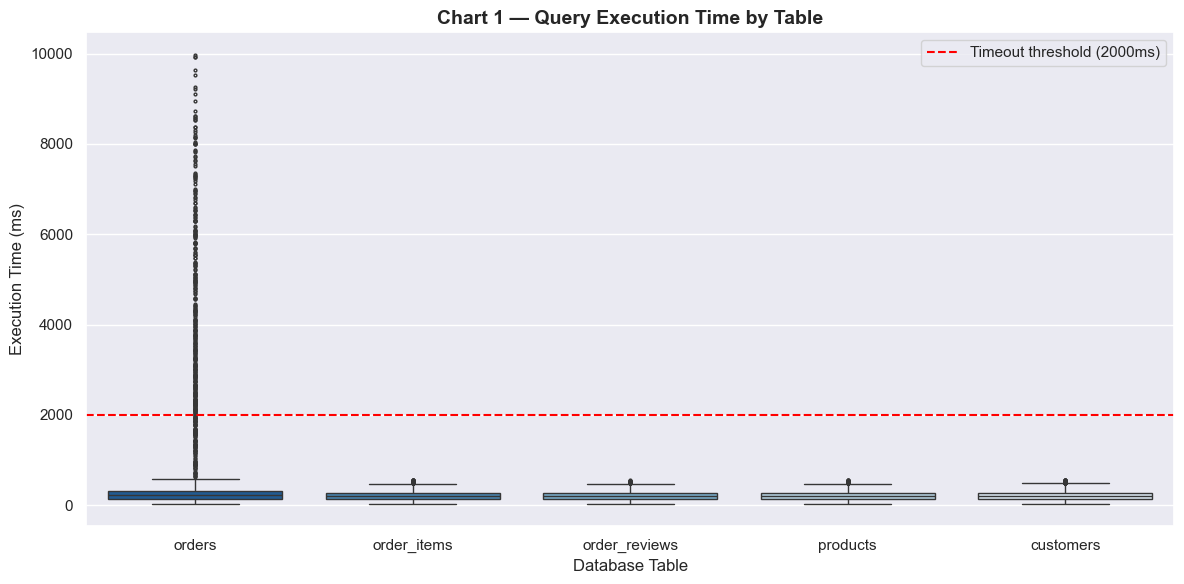

Chart 1 saved.


In [3]:
# ── Chart 1: Query execution time by table (box plot) ────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
order = (df.group_by("target_table")
           .agg(pl.col("execution_time_ms").mean().alias("avg"))
           .sort("avg", descending=True)["target_table"].to_list())

sns.boxplot(data=df.to_pandas(), x="target_table", y="execution_time_ms",
            order=order, palette="Blues_r", ax=ax, fliersize=2)
ax.axhline(2000, color="red", linestyle="--", linewidth=1.5, label="Timeout threshold (2000ms)")
ax.set_title("Chart 1 — Query Execution Time by Table", fontsize=14, fontweight="bold")
ax.set_xlabel("Database Table")
ax.set_ylabel("Execution Time (ms)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/chart1_exec_by_table.png", dpi=150)
plt.show()
print("Chart 1 saved.")


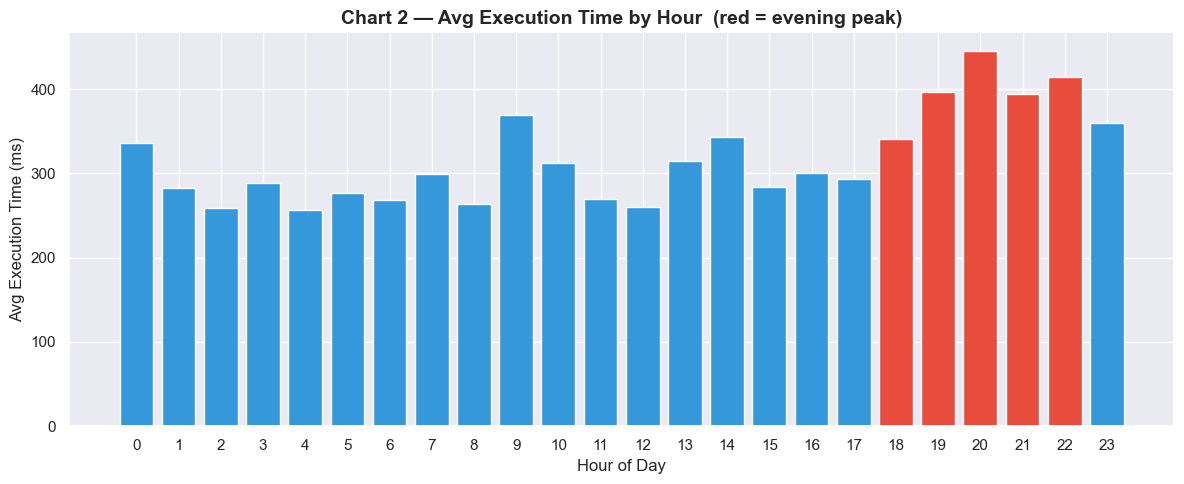

Chart 2 saved.


In [4]:
# ── Chart 2: Avg execution time by hour ──────────────────────────────────────
hourly = (conn.execute('''
    SELECT HOUR(CAST(timestamp AS TIMESTAMP)) AS hour,
           ROUND(AVG(execution_time_ms), 1)   AS avg_ms
    FROM   raw_logs
    GROUP  BY 1
    ORDER  BY 1
''').pl())

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#e74c3c" if 18 <= h <= 22 else "#3498db" for h in hourly["hour"].to_list()]
ax.bar(hourly["hour"].to_list(), hourly["avg_ms"].to_list(), color=colors, edgecolor="white")
ax.set_title("Chart 2 — Avg Execution Time by Hour  (red = evening peak)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Execution Time (ms)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(f"{FIGURES}/chart2_exec_by_hour.png", dpi=150)
plt.show()
print("Chart 2 saved.")


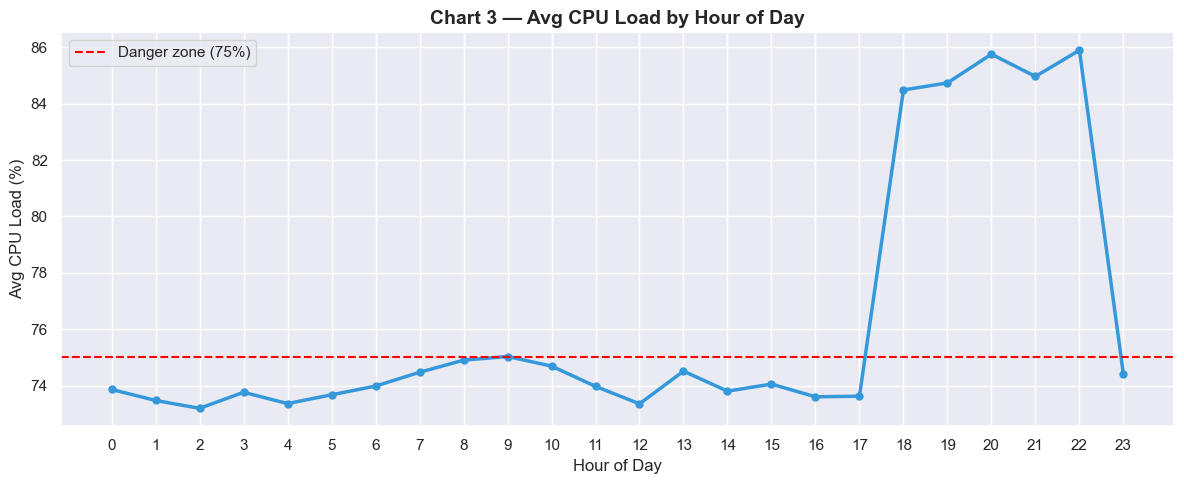

Chart 3 saved.


In [5]:
# ── Chart 3: Avg CPU load by hour ────────────────────────────────────────────
cpu_hourly = (conn.execute('''
    SELECT HOUR(CAST(timestamp AS TIMESTAMP)) AS hour,
           ROUND(AVG(server_cpu_load), 2)     AS avg_cpu
    FROM   raw_logs
    GROUP  BY 1
    ORDER  BY 1
''').pl())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cpu_hourly["hour"].to_list(), cpu_hourly["avg_cpu"].to_list(),
        color="#3498db", linewidth=2.5, marker="o", markersize=5)
ax.axhline(75, color="red", linestyle="--", linewidth=1.5, label="Danger zone (75%)")
ax.set_title("Chart 3 — Avg CPU Load by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg CPU Load (%)")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/chart3_cpu_by_hour.png", dpi=150)
plt.show()
print("Chart 3 saved.")


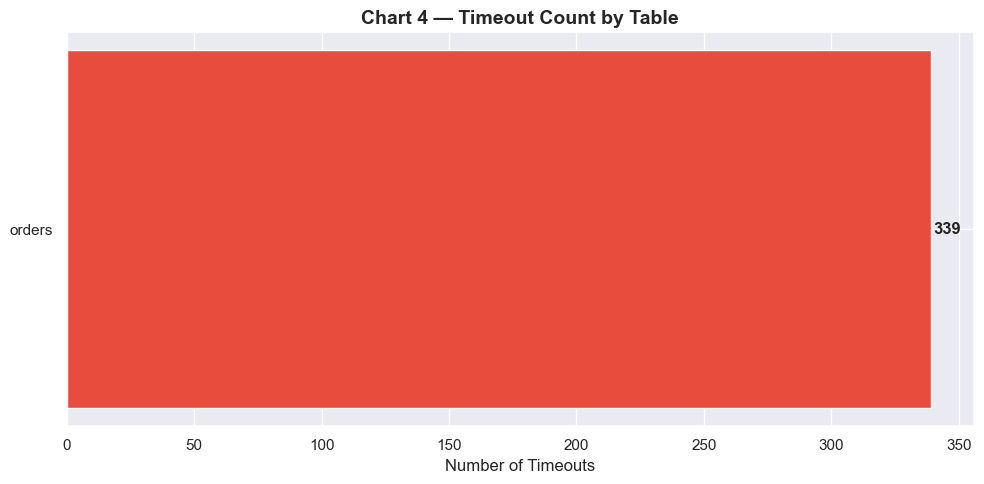

Chart 4 saved.


In [6]:
# ── Chart 4: Timeout count by table ──────────────────────────────────────────
timeout_tbl = (conn.execute('''
    SELECT target_table,
           COUNT(*) AS timeouts
    FROM   raw_logs
    WHERE  status = 'TIMEOUT'
    GROUP  BY target_table
    ORDER  BY timeouts DESC
''').pl())

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(timeout_tbl["target_table"].to_list(),
        timeout_tbl["timeouts"].to_list(),
        color="#e74c3c", edgecolor="white")
for i, v in enumerate(timeout_tbl["timeouts"].to_list()):
    ax.text(v + 1, i, str(v), va="center", fontweight="bold")
ax.set_title("Chart 4 — Timeout Count by Table", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Timeouts")
plt.tight_layout()
plt.savefig(f"{FIGURES}/chart4_timeouts_by_table.png", dpi=150)
plt.show()
conn.close()
print("Chart 4 saved.")


In [7]:
conn = duckdb.connect(DB_PATH, read_only=True)
res = conn.execute('''
    SELECT
        COUNT(*)                                               AS total,
        SUM(CASE WHEN status='TIMEOUT' THEN 1 ELSE 0 END)     AS timeouts,
        ROUND(AVG(execution_time_ms), 1)                       AS avg_ms,
        MAX(execution_time_ms)                                 AS max_ms,
        ROUND(AVG(CASE WHEN target_table='orders'
                   THEN execution_time_ms END), 1)             AS orders_avg,
        ROUND(AVG(CASE WHEN target_table<>'orders'
                   THEN execution_time_ms END), 1)             AS others_avg
    FROM raw_logs
''').fetchone()
conn.close()

total, timeouts, avg_ms, max_ms, orders_avg, others_avg = res
print("=" * 55)
print("  EDA SUMMARY")
print("=" * 55)
print(f"  Queries analysed     : {total:,}")
print(f"  Timeouts             : {timeouts:,}  ({timeouts/total:.2%})")
print(f"  Avg execution time   : {avg_ms} ms")
print(f"  Worst query          : {max_ms:,} ms")
print(f"  Orders table avg     : {orders_avg} ms  <- broken")
print(f"  All other tables avg : {others_avg} ms")
print(f"  Orders is            : {orders_avg/others_avg:.1f}x slower")
print("=" * 55)

  EDA SUMMARY
  Queries analysed     : 15,000
  Timeouts             : 339  (2.26%)
  Avg execution time   : 317.7 ms
  Worst query          : 9,975 ms
  Orders table avg     : 739.7 ms  <- broken
  All other tables avg : 210.9 ms
  Orders is            : 3.5x slower
